## Plots for the Paper

In [1]:
import json
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import polars as pl
from r_utils import fit_lmer_with_vc, fit_lmer, fit_lmer_full, format_term
from plot_utils import _configure_fonts, plot_emmeans_grouped_bar, SETTING_COLOR, SETTING_MAP, GRAPH_MAP, SETTING_MARKER, OKABE_ITO
import matplotlib.pyplot as plt

_configure_fonts()
# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

Error importing in API mode: ImportError("dlopen(/Users/gs/Documents/GitHub/llm-debate-sim/.venv/lib/python3.12/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <85D47EFD-9B5F-368A-BC00-EBCFE4080F31> /Users/gs/Documents/GitHub/llm-debate-sim/.venv/lib/python3.12/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [17]:
result_path = Path.cwd().parent / "data" / "analysis" 
COL_PRETTY_NAMES = {
    "plasticity_tv": "Plasticity",
    "monotonicity": "Directedness",
    "influence_out": "Outgoing Influence",
    'modal_consensus_change': 'Consensus Change',
    "modal_consensus_T": "Consensus",
}

## Contrasts

In [18]:
agent_contrast = pl.read_csv(result_path / "contrasts" / "agent" / "contrast_summary.csv")
run_contrast = pl.read_csv(result_path / "contrasts" / "runs" / "contrast_summary.csv")
contrasts = pd.concat([agent_contrast.to_pandas(), run_contrast.to_pandas()], ignore_index=True)
contrasts.to_csv(result_path / "contrasts" / "combined_contrasts.csv", index=False)
contrasts.sample(10)

,outcome,contrast_type,graph_type,contrast,estimate,std_estimate,SE,std_SE,t,df,p,lower,upper,std_lower,std_upper,sig
80,modal_consensus_change,marginal,NaN,role_eff,0.051823,0.407627,0.006891,0.054201,7.520676,1253.000000,1.035128e-13,0.038304,0.065342,0.301292,0.513961,True
17,plasticity_tv,marginal,NaN,model_eff,0.058531,0.495786,0.003698,0.031326,15.826656,1252.998804,1.427055e-51,0.051276,0.065787,0.434329,0.557243,True
66,polarization_T,marginal,NaN,alignment,0.023980,0.167062,0.005455,0.038000,4.396323,1253.000000,1.194236e-05,0.013279,0.034681,0.092511,0.241614,True
10,influence_out,within,watts-strogatz,alignment,0.034034,0.371053,0.005726,0.062423,5.944130,1252.997325,3.598202e-09,0.022801,0.045267,0.248587,0.493519,True
50,modal_consensus_T,marginal,NaN,alignment,-0.026302,-0.243030,0.005907,0.054579,-4.452770,1238.975097,9.240843e-06,-0.037891,-0.014713,-0.350108,-0.135951,True
74,polarization_T,within,watts-strogatz,alignment,0.027707,0.193029,0.007714,0.053741,3.591851,1253.000000,3.410496e-04,0.012573,0.042840,0.087597,0.298460,True
86,modal_consensus_change,within,erdos-renyi,alignment,-0.035937,-0.282676,0.009745,0.076652,-3.687804,1253.000000,2.358793e-04,-0.055056,-0.016819,-0.433055,-0.132296,True
95,modal_consensus_change,interaction,NaN,dissociation,0.014453,0.113685,0.009745,0.076652,1.483139,1253.000000,1.382890e-01,-0.004665,0.033571,-0.036695,0.264064,False
77,polarization_T,interaction,NaN,model_eff,-0.002413,-0.016814,0.010909,0.076001,-0.221235,1253.000000,8.249456e-01,-0.023815,0.018988,-0.165917,0.132289,False
82,modal_consensus_change,marginal,NaN,alignment,-0.036328,-0.285748,0.006891,0.054201,-5.272032,1253.000000,1.587617e-07,-0.049847,-0.022809,-0.392083,-0.179414,True


In [37]:
from tkinter import font

from matplotlib.lines import Line2D

from notebooks.plot_utils import GRAPH_COLOR

def plot_contrast_forest(
    summary,
    contrasts_order=None,
    outcomes_order=None,
    graph_types_order=("erdos-renyi", "watts-strogatz"),
    use_standardized=True,
    figsize=(14, 4.8),
):
    """Forest plot with one panel per contrast and 3 estimates per outcome.

    For each outcome row inside each contrast panel, this plots a triplet of
    estimates with CIs:
      - Marginal (pooled)
      - Within Erdos-Renyi
      - Within Watts-Strogatz

    Args:
        summary: DataFrame from build_contrast_summary.
        contrasts_order: Ordered list of contrasts to display as panels.
        outcomes_order: Ordered list of outcomes to display on y-axis.
        graph_types_order: Order of graph labels used for within contrasts.
        use_standardized: Whether to use standardized estimates/CIs.
        figsize: Matplotlib figure size.

    Returns:
        Matplotlib figure.
    """
    if contrasts_order is None:
        contrasts_order = ["role_eff", "model_eff", "alignment", "dissociation"]
    if outcomes_order is None:
        outcomes_order = summary["outcome"].unique().tolist()

    contrast_labels = {
        "role_eff": "Role Effect",
        "model_eff": "Model Effect",
        "alignment": "Role Alignment Effect",
        "dissociation": "Heterogeneity Effect",
    }

    triplet_specs = [
        ("marginal", None, "Marginal (pooled)", OKABE_ITO['blue'], 0.0),
        ("within", graph_types_order[0], "Erdos-Renyi", GRAPH_COLOR['erdos-renyi'], -0.23),
        ("within", graph_types_order[1], "Watts-Strogatz", GRAPH_COLOR['watts-strogatz'], 0.23),
    ]

    est_col = "std_estimate" if use_standardized else "estimate"
    lo_col = "std_lower" if use_standardized else "lower"
    hi_col = "std_upper" if use_standardized else "upper"

    fig, axes = plt.subplots(
        1,
        len(contrasts_order),
        figsize=figsize,
        sharey=True,
        sharex=True,
        squeeze=False,
    )
    axes = axes[0]

    y_positions = {o: i for i, o in enumerate(outcomes_order)}

    for panel_idx, (ax, contrast_name) in enumerate(zip(axes, contrasts_order)):
        sub_contrast = summary[summary["contrast"] == contrast_name]

        for y in range(len(outcomes_order)):
            ax.axhline(y+0.5, color="0.88", linewidth=0.7, alpha=0.7, zorder=0)

        for outcome in outcomes_order:
            if outcome not in y_positions:
                continue
            y_base = y_positions[outcome]

            for ctype, gtype, _, color, y_offset in triplet_specs:
                mask = sub_contrast["contrast_type"] == ctype
                if gtype is None:
                    mask &= sub_contrast["graph_type"].isna()
                else:
                    mask &= sub_contrast["graph_type"] == gtype
                mask &= sub_contrast["outcome"] == outcome

                sub = sub_contrast[mask]
                if sub.empty:
                    continue

                row = sub.iloc[0]
                is_sig = bool(row["sig"])
                alpha = 1.0 if is_sig else 0.45
                marker_face = color if is_sig else "white"

                ax.errorbar(
                    row[est_col],
                    y_base + y_offset,
                    xerr=[[row[est_col] - row[lo_col]], [row[hi_col] - row[est_col]]],
                    fmt="o",
                    color=color,
                    markerfacecolor=marker_face,
                    markeredgecolor=color,
                    capsize=3,
                    markersize=3,
                    alpha=alpha,
                    linewidth=1.5,
                )

        ax.axvline(0, color="k", linestyle="--", alpha=0.35, linewidth=1)
        ax.spines[["top", "right"]].set_visible(False)
        panel_label = chr(ord("A") + panel_idx)
        ax.set_title(
            f"({panel_label}) {contrast_labels.get(contrast_name, contrast_name)}",
            fontsize=13,
        )
        ax.set_xlabel("Cohen's d" if use_standardized else "Effect estimate", fontsize=12)
        
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(1.5)
        ax.spines["bottom"].set_linewidth(1.5)
        ax.tick_params(width=1.3, length=5)

    axes[0].set_yticks(range(len(outcomes_order)))
    axes[0].set_yticklabels([COL_PRETTY_NAMES.get(o, o) for o in outcomes_order], fontsize=12)
    

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color=color,
            markerfacecolor=color,
            markeredgecolor=color,
            linestyle="None",
            markersize=6,
            label=label,
        )
        for _, _, label, color, _ in triplet_specs
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=3,
        frameon=False,
        fontsize=12,
        bbox_to_anchor=(0.5, -0.07),
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

In [43]:
contrasts_latex = pl.from_pandas(contrasts[contrasts['outcome'].isin(COL_PRETTY_NAMES.keys()) & contrasts['contrast_type'].isin(['marginal', 'within'])])

#### Marginal

In [90]:
# contrast_labels = {
#         "role_eff": "Role Effect",
#         "model_eff": "Model Effect",
#         "alignment": "Role Alignment",
#         "dissociation": "Heterogeneity",
#     }

# def fmt_p(p: float) -> str:
#     if pd.isna(p):
#         return ""
#     return "<0.001" if p < 0.001 else f"{p:.3f}"


# lfs  = (contrasts_latex.filter(pl.col('contrast_type') == 'marginal')
#  .with_columns(pl.col('outcome').map_elements(lambda x: COL_PRETTY_NAMES.get(x, x)).alias('Outcome'))
#  .with_columns(pl.col('contrast').map_elements(lambda x: contrast_labels.get(x, x)).alias('Contrast'))
#  .select(
#      pl.col('Outcome'),
#      pl.col('Contrast'),
#      pl.col('estimate').round(3),
#      pl.col('lower').round(3),
#      pl.col('upper').round(3),
#      pl.col('SE').round(3),
#      pl.col('t').round(3),
#      pl.col('p').map_elements(fmt_p).alias('p'),
#      pl.col('df').round(3),
#  )
#  ).sort(['Outcome', 'Contrast']).to_pandas()
# lfs['Contrast'] = pd.Categorical(lfs['Contrast'], categories=['Role Effect', 'Model Effect', 'Role Alignment', 'Heterogeneity'], ordered=True)
# lfs['Outcome'] = pd.Categorical(lfs['Outcome'], categories=[COL_PRETTY_NAMES.get(o, o) for o in ['plasticity_tv', 'monotonicity', 'influence_out', 'modal_consensus_change', 'modal_consensus_T']], ordered=True)
# lfs= lfs.sort_values(['Outcome', 'Contrast']).set_index(['Outcome', 'Contrast'])



# print(lfs.to_latex(index=True,
#                 caption="Marginal contrasts on key outcomes.",
#                 multicolumn  = True,
#                 multirow     = True,
#                 escape       = False,
#                 float_format="{:0.2f}".format,
#                 label="tab:marginal-contrasts"))
    


### Conditional

In [93]:
contrasts_latex

outcome,contrast_type,graph_type,contrast,estimate,std_estimate,SE,std_SE,t,df,p,lower,upper,std_lower,std_upper,sig
str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
"""influence_out""","""marginal""",null,"""role_eff""",0.037378,0.407514,0.004049,0.04414,9.232308,1252.997328,1.0954e-19,0.029435,0.045321,0.320918,0.49411,true
"""influence_out""","""marginal""",null,"""model_eff""",0.056308,0.613896,0.004049,0.04414,13.90794,1252.997325,5.3385e-41,0.048365,0.064251,0.5273,0.700493,true
"""influence_out""","""marginal""",null,"""alignment""",0.009762,0.106433,0.004049,0.04414,2.41126,1252.997325,0.016041,0.001819,0.017705,0.019837,0.193029,true
"""influence_out""","""marginal""",null,"""dissociation""",0.079878,0.87087,0.002863,0.031212,27.902043,1252.997327,1.1927e-133,0.074262,0.085495,0.809637,0.932103,true
"""influence_out""","""within""","""erdos-renyi""","""role_eff""",0.051052,0.556593,0.005726,0.062423,8.916421,1252.997324,1.6655e-18,0.039819,0.062285,0.434127,0.679059,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""modal_consensus_change""","""within""","""erdos-renyi""","""dissociation""",0.15599,1.226977,0.006891,0.054201,22.637612,1253.0,2.1394e-95,0.142471,0.169508,1.120643,1.333311,true
"""modal_consensus_change""","""within""","""watts-strogatz""","""role_eff""",0.060417,0.475223,0.009745,0.076652,6.199787,1253.0,7.6613e-10,0.041298,0.079535,0.324844,0.625603,true
"""modal_consensus_change""","""within""","""watts-strogatz""","""model_eff""",0.129687,1.020091,0.009745,0.076652,13.308164,1253.0,6.7912e-38,0.110569,0.148806,0.869712,1.17047,true


In [99]:


contrast_labels = {
        "role_eff": "Role Effect",
        "model_eff": "Model Effect",
        "alignment": "Role Alignment",
        "dissociation": "Heterogeneity",
    }

graph_labels = {
    "erdos-renyi": "ER",
    "watts-strogatz": "WS",
}

def fmt_p(p: float) -> str:
    if pd.isna(p):
        return ""
    return "<0.001" if p < 0.001 else f"{p:.3f}"


lfs  = (contrasts_latex.filter(pl.col('contrast_type') == 'within')
 .with_columns(pl.col('outcome').map_elements(lambda x: COL_PRETTY_NAMES.get(x, x)).alias('Outcome'))
 .with_columns(pl.col('contrast').map_elements(lambda x: contrast_labels.get(x, x)).alias('Contrast'))
 .with_columns(pl.col('graph_type').map_elements(lambda x: graph_labels.get(x, x)).alias('Network'))
 .select(
     pl.col('Outcome'),
     pl.col('Contrast'),
     pl.col('Network'),
     pl.col('estimate').round(3),
     pl.col('lower').round(3),
     pl.col('upper').round(3),
     pl.col('SE').round(3),
     pl.col('t').round(3),
     pl.col('p').map_elements(fmt_p).alias('p'),
     pl.col('df').round(3),
 )
 ).sort(['Outcome', 'Contrast', 'Network']).to_pandas()
lfs['Contrast'] = pd.Categorical(lfs['Contrast'], categories=['Role Effect', 'Model Effect', 'Role Alignment', 'Heterogeneity'], ordered=True)
lfs['Outcome'] = pd.Categorical(lfs['Outcome'], categories=[COL_PRETTY_NAMES.get(o, o) for o in ['plasticity_tv', 'monotonicity', 'influence_out', 'modal_consensus_change', 'modal_consensus_T']], ordered=True)
lfs= lfs.sort_values(['Outcome', 'Network', 'Contrast']).set_index(['Outcome', 'Network', 'Contrast'])



print(lfs.to_latex(index=True,
                caption="Marginal contrasts on key outcomes.",
                multicolumn  = True,
                multirow     = True,
                escape       = False,
                float_format="{:0.2f}".format,
                label="tab:marginal-contrasts"))
    


\begin{table}
\caption{Marginal contrasts on key outcomes.}
\label{tab:marginal-contrasts}
\begin{tabular}{lllrrrrrlr}
\toprule
 &  &  & estimate & lower & upper & SE & t & p & df \\
Outcome & Network & Contrast &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{8}{*}{Plasticity} & \multirow[t]{4}{*}{ER} & Role Effect & 0.05 & 0.04 & 0.06 & 0.01 & 9.09 & <0.001 & 1253.00 \\
 &  & Model Effect & 0.06 & 0.05 & 0.07 & 0.01 & 11.24 & <0.001 & 1253.00 \\
 &  & Role Alignment & -0.02 & -0.03 & -0.01 & 0.01 & -3.17 & 0.002 & 1253.00 \\
 &  & Heterogeneity & 0.07 & 0.07 & 0.08 & 0.00 & 20.09 & <0.001 & 1253.00 \\
\cline{2-10}
 & \multirow[t]{4}{*}{WS} & Role Effect & 0.02 & 0.01 & 0.03 & 0.01 & 4.41 & <0.001 & 1253.00 \\
 &  & Model Effect & 0.06 & 0.05 & 0.07 & 0.01 & 11.14 & <0.001 & 1253.00 \\
 &  & Role Alignment & 0.03 & 0.02 & 0.04 & 0.01 & 5.52 & <0.001 & 1253.00 \\
 &  & Heterogeneity & 0.08 & 0.08 & 0.09 & 0.00 & 22.77 & <0.001 & 1253.00 \\
\cline{1-10} \cline{2-10}
\multirow[t]{8}{*}{Dire

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern pruned
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:Zapf dropped
INFO:fontTools.subset:feat dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:morx dropped
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'glyf': 43 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'H', 'I', 'M', 'O', 'P', 'R', 'S', 'W', 'a', 'c', 'd', 'e', 'f', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'quotesingle', 'r', 's', 'space', 't', 'u', 'y', 'z', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 10, 11, 12, 16, 19, 20, 36, 37, 38, 39, 40, 43, 44, 48, 50, 51, 53, 54, 58, 68, 70, 71, 72, 73, 74, 75, 76, 79, 80, 81, 82, 83, 85, 86, 87, 88, 92, 93,

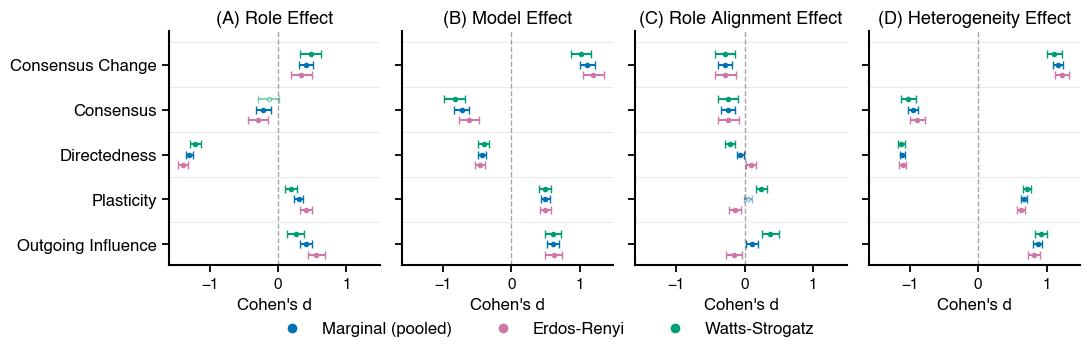

In [38]:
fig = plot_contrast_forest(contrasts[contrasts['outcome'].isin(COL_PRETTY_NAMES.keys())], 
                     use_standardized=True,
                     figsize=(11, 3.5))
fig.savefig(result_path/ "contrasts" / "contrast_forest.pdf", dpi=300, bbox_inches="tight")
plt.show()